In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt
import math, os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from typing import Tuple, List, Optional
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import List, TypeVar, Any
from torch.autograd import grad
Tensor = TypeVar('torch.tensor')

In [2]:
EPS = 1e-8

class ChannelScaler:
    def __init__(self, num_channels: int = 3):
        self.num_channels = num_channels
        self.sum = torch.zeros(num_channels, dtype=torch.float32)  
        self.sum_sq = torch.zeros(num_channels, dtype=torch.float32)  
        self.total_count = 0  
        self.mean = torch.zeros(num_channels, dtype=torch.float32)
        self.std = torch.ones(num_channels, dtype=torch.float32)
    
    def partial_fit(self, data: torch.Tensor):
        assert data.dim() == 3 and data.shape[-1] == self.num_channels
        B, T, C = data.shape
        data_flat = data.reshape(-1, C)  # [B*T, C]
        # 累计总和、平方和、总样本数
        self.sum += data_flat.sum(dim=0)  # [C]：每个通道的累计和
        self.sum_sq += (data_flat ** 2).sum(dim=0)  # [C]：每个通道的累计平方和
        self.total_count += data_flat.shape[0]  # 累计总时间步数量
    
    def finalize(self):
        self.mean = self.sum / self.total_count
        var = (self.sum_sq / self.total_count) - (self.mean ** 2)
        self.std = torch.sqrt(var.clamp(min=EPS)) 
    
    def transform(self, data: torch.Tensor) -> torch.Tensor:
        return (data - self.mean.to(data.device)) / self.std.to(data.device)
    
    def inverse_transform(self, data: torch.Tensor) -> torch.Tensor:
        return data * self.std.to(data.device) + self.mean.to(data.device)

class DummyUAVDataset(Dataset):
    def __init__(self, window_size=30, step_size=3, batch_size=8, mode='1-hover', phase='2_6'):
        self.window_size = window_size

        base_data_path = os.path.join(os.getcwd(), '..', '..', 'data', 'Dpro', mode)
        columns = ['accelerometer_m_s2[0]','accelerometer_m_s2[1]', 'accelerometer_m_s2[2]']
        # columns = ['gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 'accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]', 'magnetometer_ga[0]', 'magnetometer_ga[1]', 'magnetometer_ga[2]']
        sim_data = pd.read_csv(base_data_path + f'/all_sycn_sim_data_mode{phase}.csv', usecols=columns).to_numpy()
        raw_data = pd.read_csv(base_data_path + f'/all_sycn_raw_data_mode{phase}.csv', usecols=columns).to_numpy()
        err_data = pd.read_csv(base_data_path + f'/all_sycn_err_data_mode{phase}.csv', usecols=columns).to_numpy()
        # print(f'sim_data:{sim_data.shape} raw_data:{raw_data.shape} err_data:{err_data.shape}')

        self.dataset_x  = self.data_to_model(data=sim_data, sequence_length=window_size, step_size=step_size)
        self.dataset_y  = self.data_to_model(data=raw_data, sequence_length=window_size, step_size=step_size)
        self.dataset_e = self.data_to_model(data=err_data, sequence_length=window_size, step_size=step_size)
        print(f'dataset_x:{self.dataset_x.shape}')

        dataset = TensorDataset(self.dataset_x, self.dataset_y, self.dataset_e)
        self.dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
        
    def data_to_model(self, data, sequence_length=120, step_size=25):
        data = torch.tensor(data, dtype=float)
        sequences = []
        N = data.shape[0]
        
        for start_idx in range(0, N - sequence_length + 1, step_size):
            sequence = data[start_idx:start_idx + sequence_length]
            sequences.append(sequence)
        
        sequences = torch.stack(sequences)
        return sequences

# 1-hover 2-hover-accx-flag3-params03 4-hover-motor4-flag4-params085 5-hover-motor34-flag4-params08085 6-hover-motor234-flag4-params07508085
window_size, step_size, batch_size = 75, 5, 8
datasetuav = DummyUAVDataset(step_size=step_size, window_size=window_size, batch_size=batch_size, mode='1-hover', phase='2_6')

dataset_x:torch.Size([2299, 75, 3])


In [3]:
########### MDN helper funcs ###########
EPS = 1e-8
MAX_LOG_WEIGHTED = 20.0 
MIN_SIGMA = 1e-3   

def parse_mdn_outputs(z, K, d):
    """
    z: [B, T, out_dim] where out_dim = K*(1 + 2*d)
    returns:
      pi:   [B, T, K]
      mu:   [B, T, K, d]
      sigma:[B, T, K, d]   (std, positive)
    """
    B, T, out_dim = z.shape
    expected = K * (1 + 2 * d)
    assert out_dim == expected, f"out_dim mismatch: got {out_dim}, expected {expected}"
    # split
    z = z.view(B, T, -1)
    pi_logits = z[..., :K]                      # [B,T,K]
    mu_flat = z[..., K: K + K * d]             # [B,T,K*d]
    sigma_flat = z[..., K + K * d:]            # [B,T,K*d]
    mu = mu_flat.view(B, T, K, d)
    sigma = sigma_flat.view(B, T, K, d)
    # mixture weights with numerical stability
    pi = F.softmax(pi_logits, dim=-1)          # [B,T,K]
    # ensure positivity & numerical stability for sigma (model outputs log-sigma or raw)
    # we treat sigma_flat as unconstrained -> apply softplus or exp
    sigma = F.softplus(sigma) + 1e-6           # [B,T,K,d], softplus is stable
    return pi, mu, sigma
      
def mdn_nll(pi, mu, sigma, target, reduce_mean=True):
    B, T, K = pi.shape
    d = target.shape[-1]
    tgt = target.unsqueeze(2)  # [B,T,1,d]

    # -------------------------- 1. 强制约束关键参数（避免极端值） --------------------------
    sigma = sigma.clamp(min=MIN_SIGMA) # sigma：强制≥1e-3（比之前的1e-4更大，减少 -log(sigma) 的极端正值）
    pi = pi.clamp(min=1e-8, max=1.0) # pi：强制在[1e-8, 1.0]，避免log(pi)异常

    # -------------------------- 2. 分步计算高斯成分的对数概率 --------------------------
    
    var_term = ((tgt - mu) / sigma) ** 2 # 方差项：(x - mu)^2 / sigma² → [B,T,K,d]
    exp_term = -0.5 * torch.sum(var_term, dim=-1)  # [B,T,K] # 指数项：-0.5 * sum_d(var_term) → 最大为0（x=mu时），最小为-∞
    log_sigma_term = -torch.sum(torch.log(sigma), dim=-1)  # [B,T,K] # log(sigma)项：-sum_d(log(sigma)) → sigma=1e-3时，该项= -3*log(1e-3)≈20.7，可控
    const = -0.5 * d * math.log(2 * math.pi)  # # 常数项：-0.5*d*log(2π) → d=3时≈-1.732（固定负值，抵消部分正值）
    log_prob_k = exp_term + log_sigma_term + const  # [B,T,K] # 单个高斯成分的对数概率：log(p_k(x)) = exp_term + log_sigma_term + const

    # -------------------------- 3. 计算混合成分的加权对数概率 --------------------------
    log_pi = torch.log(pi)  # [B,T,K]
    log_weighted = log_pi + log_prob_k  # [B,T,K] # 对数加权概率：log(pi_k * p_k(x)) = log_pi + log_prob_k
    log_weighted = log_weighted.clamp(max=MAX_LOG_WEIGHTED) # 关键约束：限制单成分的最大值（避免溢出导致logsumexp异常）

    # -------------------------- 4. log-sum-exp计算（保证数值稳定） --------------------------
    log_prob = torch.logsumexp(log_weighted, dim=-1)  # [B,T] # log(p(x)) = log(sum(exp(log_weighted_k))) → 理论≤0
    log_prob = log_prob.clamp(max=0.0) # 终极保障：强制log_prob ≤ 0（即使数值计算有偏差，也不让NLL为负）

    # -------------------------- 5. 计算NLL（确保非负） --------------------------
    nll = -log_prob  # [B,T]，nll ≥ 0

    if reduce_mean:
        return torch.mean(nll)
    else:
        return nll

def mdn_sample_step(pi, mu, sigma, temperature: float = 1.0):
    """
    Sample one step from mixture.
    pi: [B, K], mu: [B, K, d], sigma: [B, K, d]
    returns sampled tensor [B, d]
    """
    B, K, d = mu.shape
    pi_logits = torch.log(pi + EPS)
    pi_scaled = torch.softmax(pi_logits / temperature, dim=1)
    # sample component index for each batch
    comp = torch.multinomial(pi_scaled, num_samples=1).squeeze(-1)  # [B]
    idx = comp.view(B, 1, 1).expand(-1, 1, d)               # [B,1,d]
    mu_sel = torch.gather(mu, dim=1, index=idx).squeeze(1)  # [B,d]
    sigma_sel = torch.gather(sigma, dim=1, index=idx).squeeze(1)  # [B,d]
    eps = torch.randn_like(mu_sel)
    return mu_sel + sigma_sel * eps

def channel_wise_kl_loss(gen_mean: torch.Tensor, gen_var: torch.Tensor, 
                         real_mean: torch.Tensor, real_var: torch.Tensor) -> torch.Tensor:
    # gen_mean/gen_var: [B,T,C]，real_mean/real_var: [C]（全局统计）
    C = gen_mean.shape[-1]
    kl_per_channel = []
    for c in range(C):
        # 单通道KL散度：KL(N(μ1,σ1²) || N(μ2,σ2²))
        kl = torch.log(torch.sqrt(real_var[c]) / torch.sqrt(gen_var[..., c] + EPS)) + \
            (gen_var[..., c] + (gen_mean[..., c] - real_mean[c])**2) / (2 * real_var[c]) - 0.5
        kl_per_channel.append(torch.mean(kl))
    return torch.mean(torch.stack(kl_per_channel))  # 平均所有通道的KL损失

def temporal_smooth_loss(x: torch.Tensor) -> torch.Tensor:
    # x: [B,T,C]，计算相邻时间步的L1差
    return torch.mean(torch.abs(x[:, 1:, :] - x[:, :-1, :]))

def mdn_conditional_mean(pi, mu):
    """
    Compute conditional expectation E[x] = sum_k pi_k * mu_k
    pi: [B,T,K], mu: [B,T,K,d] -> returns [B,T,d]
    """
    # expand & sum
    # pi[..., None] * mu -> [B,T,K,d]
    mean = torch.sum(pi.unsqueeze(-1) * mu, dim=2)  # [B,T,d]
    return mean

def mdn_mixture_covariance(pi, mu, sigma):
    """
    Compute mixture covariance per time-step:
      Cov = sum_k pi_k (Sigma_k + mu_k mu_k^T) - mu_bar mu_bar^T
    pi: [B,T,K], mu: [B,T,K,d], sigma: [B,T,K,d] (sigma is std)
    returns: cov_diag [B,T,d] (diagonal covariance across dims)
    Note: we return diagonal cov for simplicity (matches diagonal Gaussian assumption).
    """
    # convert sigma (std) to var
    var = sigma ** 2  # [B,T,K,d]
    mu_bar = mdn_conditional_mean(pi, mu)  # [B,T,d]
    # compute E[xx^T] diagonal = sum_k pi_k (var_k + mu_k^2)
    exx_diag = torch.sum(pi.unsqueeze(-1) * (var + mu ** 2), dim=2)  # [B,T,d]
    cov_diag = exx_diag - mu_bar ** 2  # [B,T,d]
    return cov_diag  # diagonal of covariance

class TemporalConvBlock(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, kernel_size: int = 3, dilation: int = 1, stride: int = 1):
        super().__init__()
        padding = dilation * (kernel_size - 1) // 2 ,  
        self.conv = nn.Conv1d(
            in_channels=in_dim,
            out_channels=out_dim,
            kernel_size=kernel_size,
            padding=padding,
            dilation=dilation,
            stride=stride
        )
        self.norm = nn.LayerNorm(out_dim)  
        self.act = nn.GELU()
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, C] -> 转换为[B, C, T]适配Conv1d
        x_trans = x.permute(0, 2, 1)  # [B, C, T]
        conv_out = self.conv(x_trans).permute(0, 2, 1)  # [B, T, out_dim]
        return self.act(self.norm(conv_out))

class ErrGenerator(nn.Module):
    def __init__(self, 
                 out_dim: int = 3,         
                 cond_dim: int = 0,        
                 hidden_size: int = 512,    
                 num_layers: int = 3,       
                 fc_dim: int = 256,        
                 num_mixtures: int = 32,   
                 act: str = 'gelu',         
                 kernel_size: int = 3):    
        super().__init__()
        self.d = out_dim
        self.cond_dim = cond_dim
        self.inp_dim = out_dim + cond_dim  
        self.num_mixtures = num_mixtures

        self.temporal_conv = TemporalConvBlock(
            in_dim=self.inp_dim,
            out_dim=hidden_size,
            kernel_size=kernel_size
        )

        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2,  
            bidirectional=False
        )

        self.fc_block = nn.Sequential(
            nn.Linear(hidden_size, fc_dim),
            nn.LayerNorm(fc_dim),  # 层归一化（原无，稳定训练）
            nn.GELU(),
            nn.Dropout(0.2),       # dropout防过拟合
            nn.Linear(fc_dim, num_mixtures * (1 + 2 * self.d))  # MDN参数：K*(1+2d)
        )

    def forward(self, prev_E: torch.Tensor, cond: Optional[torch.Tensor] = None, 
                hidden: Optional[Tuple[torch.Tensor, torch.Tensor]] = None) -> Tuple[torch.Tensor, ...]:
        B, T, d_ = prev_E.shape
        assert d_ == self.d, f"prev_E channel mismatch: got {d_}, expected {self.d}"

        if self.cond_dim > 0:
            assert cond is not None and cond.shape[:2] == (B, T)
            inp = torch.cat([prev_E, cond], dim=-1)  # [B, T, d+cond_dim]
        else:
            inp = prev_E  # [B, T, d]

        # 1. 时序卷积提取局部特征
        conv_out = self.temporal_conv(inp)  # [B, T, hidden_size]
        
        # 2. LSTM提取全局时序特征
        lstm_out, hidden = self.lstm(conv_out, hidden)  # [B, T, hidden_size]

        # 4. 输出MDN参数
        z = self.fc_block(lstm_out)  # [B, T, K*(1+2d)]
        pi, mu, sigma = parse_mdn_outputs(z, self.num_mixtures, self.d)

        return pi, mu, sigma, hidden

    @torch.no_grad()
    def sample(self, 
               seq_len: int, 
               batch_size: int = 1, 
               device: str = 'cpu', 
               start_input: Optional[torch.Tensor] = None, 
               cond_seq: Optional[torch.Tensor] = None,
               temperature: float = 1.0) -> torch.Tensor:
        
        d = self.d
        if start_input is None:
            prev = torch.zeros(batch_size, 1, d, device=device)  # [B, 1, d]
        else:
            prev = start_input.view(batch_size, 1, d).to(device)

        # 初始化LSTM隐藏状态
        h0 = torch.zeros(self.lstm.num_layers, batch_size, self.lstm.hidden_size, device=device)
        c0 = torch.zeros(self.lstm.num_layers, batch_size, self.lstm.hidden_size, device=device)
        hidden = (h0, c0)

        samples = []
        for t in range(seq_len):
            # 构建当前步输入（误差+条件）
            if self.cond_dim > 0 and cond_seq is not None:
                cond_t = cond_seq[:, t:t+1, :]  # [B, 1, cond_dim]
                inp = torch.cat([prev, cond_t], dim=-1)  # [B, 1, inp_dim]
            else:
                inp = prev  # [B, 1, inp_dim]

            conv_out = self.temporal_conv(inp)
            lstm_out, hidden = self.lstm(conv_out, hidden)
            z = self.fc_block(lstm_out)  # [B, 1, K*(1+2d)]
            pi, mu, sigma = parse_mdn_outputs(z, self.num_mixtures, d)
            pi_step = pi.squeeze(1)  # [B, K]
            mu_step = mu.squeeze(1)  # [B, K, d]
            sigma_step = sigma.squeeze(1)  # [B, K, d]
            next_x = mdn_sample_step(pi_step, mu_step, sigma_step, temperature=temperature)  # [B, d]
            samples.append(next_x.unsqueeze(1))
            prev = next_x.unsqueeze(1)  # [B, 1, d]

        return torch.cat(samples, dim=1)  # [B, seq_len, d]

def wasserstein_loss(x, recon_x, std_weight=2):
    """
    计算 Wasserstein 损失（即 Earth Mover's Distance）
    :param x: 原始输入序列, 形状为 [batch_size, seq_len, input_dim]
    :param recon_x: 重建的序列, 形状为 [batch_size, seq_len, input_dim]
    :return: Wasserstein 损失
    """
    mean_x = torch.mean(x, dim=(0, 1))  # 计算原始数据的均值 [batch_size]
    std_x = torch.std(x, dim=(0, 1))    # 计算原始数据的标准差 [batch_size]

    mean_recon_x = torch.mean(recon_x, dim=(0, 1))  # 计算重建数据的均值 [batch_size]
    std_recon_x = torch.std(recon_x, dim=(0, 1))    # 计算重建数据的标准差 [batch_size]

    # 计算 Wasserstein 距离（均值差异 + 标准差差异）
    # Wasserstein 距离是均值差异和标准差差异的组合
    loss = torch.mean(torch.abs(mean_x - mean_recon_x) + std_weight * torch.abs(std_x - std_recon_x))

    return loss 

In [4]:
# ------------------------------
# Generator training for one epoch
# ------------------------------
def train_generator_epoch(generator: ErrGenerator, 
                          dataloader, 
                          scaler: ChannelScaler,  # 通道标准化工具
                          opt_G: torch.optim.Optimizer, 
                          device: str,
                          lambda_mdn: float = 1.0,    # MDN-NLL权重（核心）
                          lambda_kl: float = 0.5,     # 通道KL损失权重（新增）
                          lambda_smooth: float = 0.1, # 时序平滑损失权重（新增）
                          lambda_recon: float = 0.1,  # 重构损失权重（降低，避免压制多样性）
                          clip_grad: Optional[float] = 5.0) -> Tuple[float, ...]:
    generator.train()
    total_loss = 0.0
    total_nll = 0.0
    total_kl = 0.0
    total_smooth = 0.0
    total_recon = 0.0
    total_samples = 0

    real_mean = scaler.mean.to(device)  # [C]
    real_var = (scaler.std ** 2).to(device)  # [C]

    for _, _, err in dataloader:
        real_err = err.to(device, dtype=torch.float32)
        real_err_norm = scaler.transform(real_err)
        B, T, d = real_err_norm.shape
        total_samples += B

        x_in = real_err_norm[:, :-1, :]  # [B, T-1, d]
        x_target = real_err_norm[:, 1:, :]  # [B, T-1, d]
        cond_for_gen = None  
        pi, mu, sigma, _ = generator(x_in, cond=cond_for_gen)

        nll_loss = mdn_nll(pi, mu, sigma, x_target)

        fake_mean = torch.sum(pi.unsqueeze(-1) * mu, dim=2)  # [B, T-1, d]：生成误差的均值
        fake_seq_norm = torch.cat([torch.zeros(B, 1, d, device=device), fake_mean], dim=1)  # [B, T, d]
        # recon_loss = torch.mean(torch.square(real_err_norm - fake_seq_norm))
        recon_loss = torch.mean(torch.abs(real_err_norm - fake_seq_norm))

        fake_var = torch.sum(pi.unsqueeze(-1) * (sigma ** 2 + mu ** 2), dim=2) - (fake_mean ** 2)  # [B, T-1, d]
        kl_loss = channel_wise_kl_loss(fake_mean, fake_var, real_mean, real_var)

        smooth_loss = temporal_smooth_loss(fake_seq_norm)

        total_loss_G = (lambda_mdn * nll_loss +
                        lambda_kl * kl_loss +
                        lambda_smooth * smooth_loss +
                        lambda_recon * recon_loss)

        opt_G.zero_grad()
        total_loss_G.backward()
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(generator.parameters(), clip_grad) 
        opt_G.step()

        total_loss += total_loss_G.item() * B
        total_nll += nll_loss.item() * B
        total_kl += kl_loss.item() * B
        total_smooth += smooth_loss.item() * B
        total_recon += recon_loss.item() * B

    avg_loss = total_loss / total_samples
    avg_nll = total_nll / total_samples
    avg_kl = total_kl / total_samples
    avg_smooth = total_smooth / total_samples
    avg_recon = total_recon / total_samples

    return avg_loss, avg_nll, avg_kl, avg_smooth, avg_recon

def train_errCompensator(generator: ErrGenerator, 
                         dataloader,
                         scaler: ChannelScaler,  # 通道标准化工具
                         device: str = 'cpu',
                         gen_opt: Optional[torch.optim.Optimizer] = None,
                         num_iters: int = 50,  # 建议延长训练迭代（原10，确保收敛）
                         lambda_mdn: float = 1.0,
                         lambda_kl: float = 0.5,
                         lambda_smooth: float = 0.1,
                         lambda_recon: float = 0.1,
                         clip_grad: float = 5.0) -> Tuple[ErrGenerator, dict]:
    generator.to(device)
    if gen_opt is None:
        gen_opt = torch.optim.AdamW(generator.parameters(), lr=1e-4, weight_decay=1e-5)
    
    loss_records = {
        'total_loss': [],
        'nll_loss': [],
        'kl_loss': [],
        'smooth_loss': [],
        'recon_loss': []
    }

    for it in range(num_iters):
        avg_loss, avg_nll, avg_kl, avg_smooth, avg_recon = train_generator_epoch(
            generator=generator,
            dataloader=dataloader,
            scaler=scaler,
            opt_G=gen_opt,
            device=device,
            lambda_mdn=lambda_mdn,
            lambda_kl=lambda_kl,
            lambda_smooth=lambda_smooth,
            lambda_recon=lambda_recon,
            clip_grad=clip_grad
        )

        print(f"Epoch {it+1}/{num_iters} | "
              f"Total Loss: {avg_loss:.6f} | "
              f"NLL: {avg_nll:.6f} | "
              f"KL: {avg_kl:.6f} | "
              f"Smooth: {avg_smooth:.6f} | "
              f"Recon: {avg_recon:.6f}")

        loss_records['total_loss'].append(avg_loss)
        loss_records['nll_loss'].append(avg_nll)
        loss_records['kl_loss'].append(avg_kl)
        loss_records['smooth_loss'].append(avg_smooth)
        loss_records['recon_loss'].append(avg_recon)

    return generator, loss_records


In [5]:
# --- instantiate models ---
dataloader = datasetuav.dataloader
scaler = ChannelScaler(num_channels=3)  
for _, _, err in dataloader:
    scaler.partial_fit(err)  
scaler.finalize()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = ErrGenerator(out_dim=3, hidden_size=256, num_layers=3, num_mixtures=64, kernel_size=3).to(device)

# --- optimizers ---
gen_opt = torch.optim.AdamW(generator.parameters(), lr=1e-3)

In [6]:
# --- run training (uses the train_errCompensator implementation provided earlier) ---
generator, loss_records = train_errCompensator(
    generator=generator,
    dataloader=dataloader,
    scaler=scaler,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    gen_opt=gen_opt,
    num_iters=50, 
    lambda_mdn=1.0,
    lambda_kl=1.5,  
    lambda_smooth=0.1,
    lambda_recon=1.0 
)

Epoch 1/50 | Total Loss: 3.897373 | NLL: 2.540384 | KL: 0.419601 | Smooth: 0.141560 | Recon: 0.713432
Epoch 2/50 | Total Loss: 1.823476 | NLL: 0.744758 | KL: 0.232343 | Smooth: 0.130406 | Recon: 0.717163
Epoch 3/50 | Total Loss: 1.606895 | NLL: 0.585201 | KL: 0.189931 | Smooth: 0.118962 | Recon: 0.724901
Epoch 4/50 | Total Loss: 1.526353 | NLL: 0.529287 | KL: 0.171556 | Smooth: 0.113874 | Recon: 0.728345
Epoch 5/50 | Total Loss: 1.448669 | NLL: 0.472380 | KL: 0.155904 | Smooth: 0.109733 | Recon: 0.731459
Epoch 6/50 | Total Loss: 1.447717 | NLL: 0.471672 | KL: 0.156059 | Smooth: 0.109890 | Recon: 0.730968
Epoch 7/50 | Total Loss: 1.404297 | NLL: 0.441585 | KL: 0.146086 | Smooth: 0.107093 | Recon: 0.732873
Epoch 8/50 | Total Loss: 1.373177 | NLL: 0.418638 | KL: 0.140227 | Smooth: 0.105599 | Recon: 0.733638
Epoch 9/50 | Total Loss: 1.378655 | NLL: 0.422154 | KL: 0.141974 | Smooth: 0.106333 | Recon: 0.732906
Epoch 10/50 | Total Loss: 1.332906 | NLL: 0.391034 | KL: 0.130725 | Smooth: 0.1029

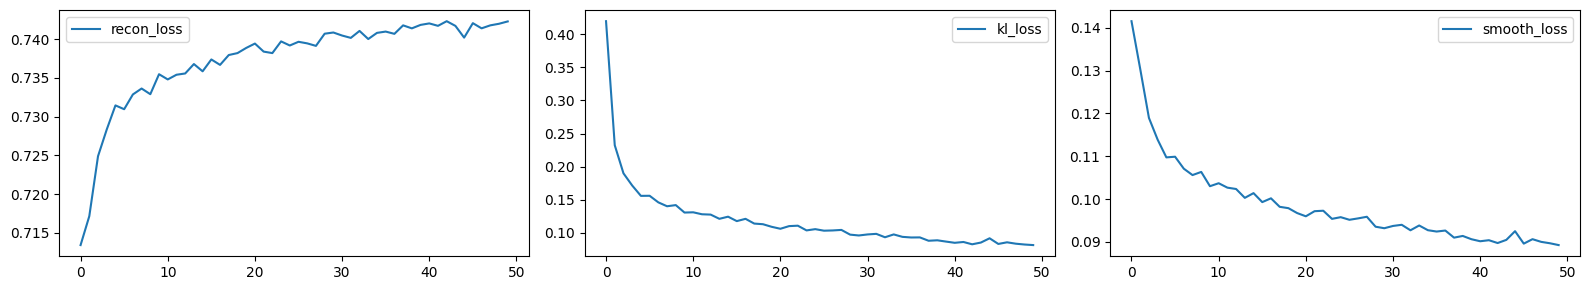

In [7]:
plt.figure(figsize=(16, 3))
plt.subplot(1, 3, 1)
plt.plot(loss_records['recon_loss'], label="recon_loss")
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(loss_records['kl_loss'], label="kl_loss")
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(loss_records['smooth_loss'], label="smooth_loss")
plt.legend()
plt.tight_layout()
plt.show()

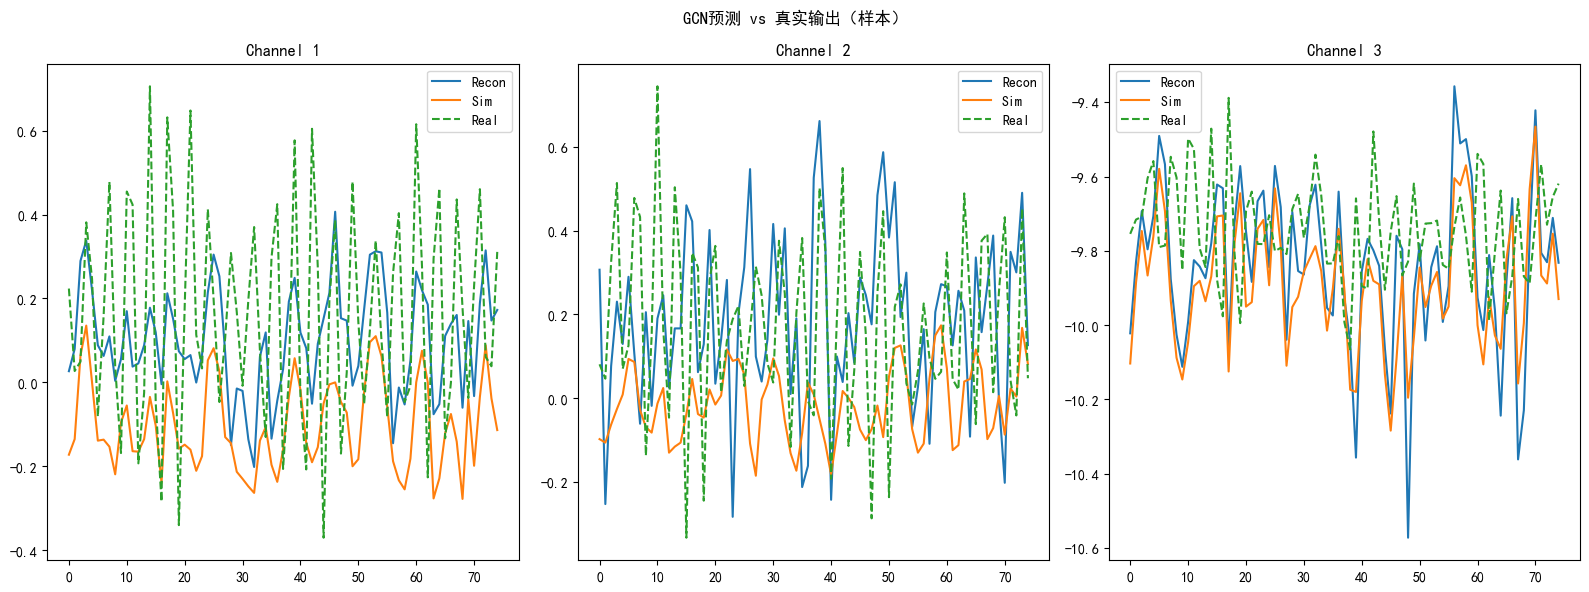

✅ 测试集评估指标:
    MSE: 0.137651
    MAE: 0.279733
    RMSE: 0.368261
    R² Score: -0.237482
    Wasserstein Distance: 0.186207


In [9]:
from scipy.stats import wasserstein_distance

def calculate_wasserstein_distance(pred, true):
    """计算Wasserstein距离（Earth Mover's Distance）"""
    wasserstein_dist = 0
    D = pred.shape[1]  # 特征数
    
    for d in range(D):
        pred_data = pred[:, d].cpu().numpy()
        true_data = true[:, d].cpu().numpy()
        # 计算单特征的Wasserstein距离
        wasserstein_dist += wasserstein_distance(pred_data, true_data)
    
    return wasserstein_dist / D  # 返回所有特征的平均距离

def evaluate(model, test_loader, device, scaler, look_id=4, temperature=1.3):
    model.eval()
    metrics = {
        'mse': 0.0,
        'mae': 0.0,
        'rmse': 0.0,
        'r2': 0.0,
        'wasserstein': 0.0,
    }
    count = 0
    predictions = []
    true_data = []
    origin_sim = []
    with torch.no_grad():
        for xb, yb, eb in test_loader:
            B, T, F_in = xb.shape
            generated_err_norm  = model.sample(seq_len=T, batch_size=batch_size, device=device, temperature=temperature)
            gen = scaler.inverse_transform(generated_err_norm)

            h = xb.view(xb.size(0), -1, F_in).to(device)
            raw = yb.view(yb.size(0), -1, F_in).to(device)

            pred_err = gen.view(gen.size(0), -1, F_in).to(device) 
            predictions.append(xb.to(device) - pred_err)
            true_data.append(raw.to(device))
            origin_sim.append(xb.to(device))

            # 计算单批次指标（按样本和特征平均）
            B, W, F_in = pred_err.shape
            pred_flat = pred_err.view(-1, F_in)  # [B*W, F]
            true_flat = eb.view(-1, F_in).to(device)  # [B*W, F]
            # print(f'pred_flat device:{pred_flat.device} true_flat device:{true_flat.device}')
            # 基本误差指标
            metrics['mse'] += F.mse_loss(pred_flat, true_flat).item()
            metrics['mae'] += F.l1_loss(pred_flat, true_flat).item()
            metrics['rmse'] += torch.sqrt(F.mse_loss(pred_flat, true_flat)).item()
            
            # R²（决定系数）
            ss_total = torch.sum((true_flat - true_flat.mean(dim=0)) **2, dim=0)  # 总变异
            ss_resid = torch.sum((true_flat - pred_flat)** 2, dim=0)  # 残差变异
            r2 = torch.mean(1 - ss_resid / (ss_total + 1e-6)).item()  # 平均所有特征的R²
            metrics['r2'] += r2

            # 分布特征指标
            metrics['wasserstein'] += calculate_wasserstein_distance(pred_flat, true_flat)

            count += 1

            # 可视化指定样本
            if count == look_id:
                pred_np = pred_err[0].detach().cpu().numpy()     # [W, 9]
                real_np = raw[0].detach().cpu().numpy()   # [W, 9]
                sim_np = h[0].detach().cpu().numpy()              # [W, 10]
                recon_np = sim_np - pred_np

                plt.figure(figsize=(16, 6))
                for i in range(3):  # 可选展示前三个通道
                    plt.subplot(1, 3, i+1)
                    plt.plot(recon_np[:, i], label="Recon")
                    plt.plot(sim_np[:, i], label="Sim")
                    plt.plot(real_np[:, i], label="Real", linestyle='--')
                    plt.title(f'Channel {i+1}')
                    plt.legend()
                plt.suptitle("GCN预测 vs 真实输出（样本）")
                plt.tight_layout()
                plt.show()

    compensated_dataset_x = torch.cat(predictions, dim=0)
    raw_dataset_y = torch.cat(true_data, dim=0)
    origin_dataset_x = torch.cat(origin_sim, dim=0)

    for key in metrics:
        metrics[key] /= count

    print(f"✅ 测试集评估指标:")
    print(f"    MSE: {metrics['mse']:.6f}")
    print(f"    MAE: {metrics['mae']:.6f}")
    print(f"    RMSE: {metrics['rmse']:.6f}")
    print(f"    R² Score: {metrics['r2']:.6f}")
    print(f"    Wasserstein Distance: {metrics['wasserstein']:.6f}")

    return compensated_dataset_x, raw_dataset_y, origin_dataset_x

dataloader = datasetuav.dataloader
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

compensated_dataset_x, raw_dataset_y, origin_dataset_x = evaluate(generator, dataloader, device = 'cuda' if torch.cuda.is_available() else 'cpu', scaler=scaler, look_id=50, temperature=1)


recovered_sim_data shape: (11550, 3) recovered_raw_data shape: (11550, 3)


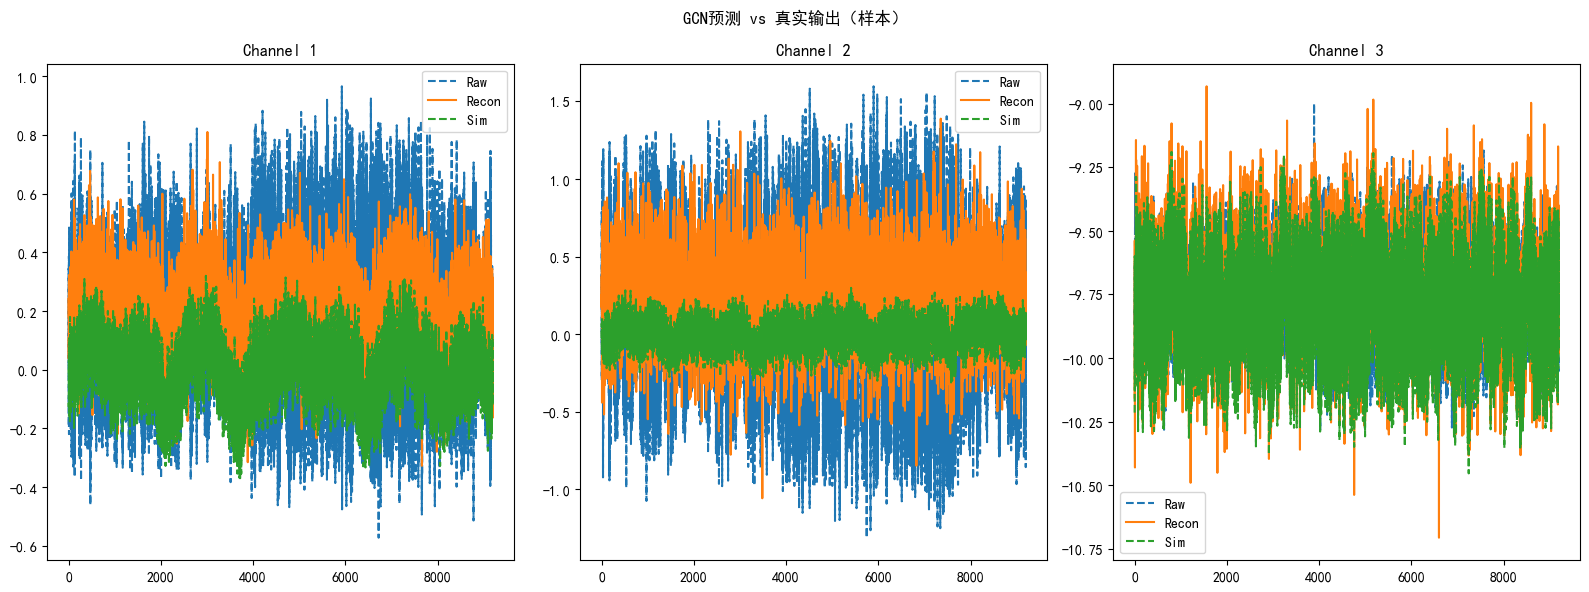

In [15]:
def reverse_data_to_model(compensated_dataset_x, sequence_length, step_size):
    compensated_dataset_x = compensated_dataset_x.cpu().numpy() 
    num_sequences, W, feature_num = compensated_dataset_x.shape  
    
    original_length = (num_sequences - 1) * step_size + sequence_length
    
    recovered_data = np.zeros((original_length, feature_num), dtype=np.float32)
    counts = np.zeros((original_length, feature_num), dtype=np.float32)  
    
    for seq_idx in range(num_sequences):
        start_idx = seq_idx * step_size  
        end_idx = start_idx + sequence_length
        seq = compensated_dataset_x[seq_idx]
        
        recovered_data[start_idx:end_idx] += seq
        counts[start_idx:end_idx] += 1
    
    # 5. 核心修改：仅重叠部分（counts > 1）除以计数，无重叠部分（counts == 1）不操作
    # counts == 0：未被任何序列覆盖，保持0；counts == 1：无重叠，保留累加值；counts > 1：重叠，取平均
    mask_overlap = counts > 1  # 重叠位置的掩码（True表示重叠）
    recovered_data[mask_overlap] = recovered_data[mask_overlap] / counts[mask_overlap]

    return recovered_data

def reverse_data_to_model2(compensated_dataset_x, sequence_length, step_size, strategy='center'):
    if isinstance(compensated_dataset_x, torch.Tensor):
        seq = compensated_dataset_x.detach().cpu().numpy()
    else:
        seq = np.asarray(compensated_dataset_x)
    
    S, L, F = seq.shape
    assert L == sequence_length, f"sequence_length ({sequence_length}) != sequences L ({L})"
    N_rec = (S - 1) * step_size + sequence_length

    if strategy not in ('center', 'last', 'first'):
        raise ValueError("strategy must be 'center', 'last' or 'first'")

    # 快速处理单序列（无重叠）情况
    if S == 1:
        return seq[0].astype(np.float32)

    # 预分配
    recovered = np.zeros((N_rec, F), dtype=seq.dtype)
    # 为策略 'center' 我们需要记录候选值与其“距离中心”的度量
    if strategy == 'center':
        # 初始化距离为 +inf，越小越优先
        best_dist = np.full((N_rec,), np.inf, dtype=np.float64)
        center = (sequence_length - 1) / 2.0  # 窗口中心（可为非整数）
        # 遍历每个序列窗口，检查覆盖区间
        for i in range(S):
            start = i * step_size
            end = start + sequence_length
            # t 的本地位置 local_pos = t - start, 范围 0..L-1
            # 对区间内每个 t，计算 distance = abs(local_pos - center)
            # 向量化处理：
            local_positions = np.arange(sequence_length)  # 0..L-1
            dists = np.abs(local_positions - center)     # length L
            # 对每个时间点 t = start + k:
            for k in range(sequence_length):
                t = start + k
                dist = dists[k]
                if dist < best_dist[t]:
                    best_dist[t] = dist
                    recovered[t] = seq[i, k]
                # 若相等（几乎不会出现），保留已记录（可改为后写或先写）
        return recovered.astype(np.float32)

    elif strategy == 'last':
        # 后写覆盖：按序列顺序写入，每次直接覆盖（等同于最后出现的序列胜出）
        for i in range(S):
            start = i * step_size
            end = start + sequence_length
            recovered[start:end] = seq[i]
        return recovered.astype(np.float32)

    else:  # strategy == 'first'
        # 先写保留：第一次写进的值不被后续覆盖
        filled = np.zeros((N_rec,), dtype=bool)
        for i in range(S):
            start = i * step_size
            end = start + sequence_length
            for k in range(sequence_length):
                t = start + k
                if not filled[t]:
                    recovered[t] = seq[i, k]
                    filled[t] = True
        return recovered.astype(np.float32)

recovered_sim_data = reverse_data_to_model2(
    compensated_dataset_x=compensated_dataset_x,
    sequence_length=window_size,
    step_size=5
) 

recovered_raw_data = reverse_data_to_model2(
    compensated_dataset_x=raw_dataset_y,
    sequence_length=window_size,
    step_size=5
)

recovered_raw_sim_data = reverse_data_to_model2(
    compensated_dataset_x=origin_dataset_x,
    sequence_length=window_size,
    step_size=5
)

print(f'recovered_sim_data shape: {recovered_sim_data.shape} recovered_raw_data shape: {recovered_raw_data.shape}')
plt.figure(figsize=(16, 6))
length_ = 9200
for i in range(recovered_sim_data.shape[1]):  
    plt.subplot(1, 3, i+1)
    plt.plot(recovered_raw_data[:length_, i], label="Raw", linestyle='--')
    plt.plot(recovered_sim_data[:length_, i], label="Recon")
    plt.plot(recovered_raw_sim_data[:length_, i], label="Sim", linestyle='--')
    plt.title(f'Channel {i+1}')
    plt.legend()
plt.suptitle("GCN预测 vs 真实输出（样本）")
plt.tight_layout()
plt.show()



In [57]:
import shutil

ReSaved = True

mode_name = 'EC_TFCritic_ACC_HOVER_M3F4.pth'
folder_name = mode_name.split('.')[0]
folder_path = os.path.join(os.getcwd(), folder_name)
path = os.path.join(os.getcwd(), folder_name, mode_name)

if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)

torch.save(gen, path)
print(f'Model Re-Saved to {path}')


Model Re-Saved to d:\TJH\Platform\PHM\model\compare\EC_TFCritic_ACC_HOVER_M3F4\EC_TFCritic_ACC_HOVER_M3F4.pth
